# Modules import

In [ ]:
import numpy as np
import pandas as pd
import megatron.config as config
import plotly.io as pio


# Set global config variables for running session
config.set_config(
    SEASONAL_PERIOD=7,
    FH_SIZE=16,
    MAX_LAG_W_SIZE=30,
    MIN_DATE=pd.to_datetime("2015-01-01"),
    MAX_DATE=pd.to_datetime("2017-12-31"),
    COUNTRY="EC",
)

from megatron.visualization import classifiedSeriesPlot
from megatron.transformers import Mapper, DemandClassifier

np.random.seed(config.SEED)  # type: ignore
pio.renderers.default = "png"

# Synthetic data

In [ ]:
# Functions to generate different classes of time series demand


def generate_smooth(n, base=20, noise_std=1, seasonality_amp=3):
    t = np.arange(n)
    seasonal = seasonality_amp * np.sin(2 * np.pi * t / 7)
    noise = np.random.normal(0, noise_std, n)
    base = np.sort(np.random.choice([base, base + 3], size=n, p=[0.8, 0.2]))
    return np.clip(base + seasonal + noise, 0, None)


def generate_erratic(n, base=20, noise_std=10):
    noise = np.random.normal(0, noise_std, n)
    y = base + noise + np.random.choice([0, 100], size=n, p=[0.95, 0.05])
    j, k = 90, 120
    for i in range(n):
        if j <= i <= k:
            y[i] = 0
    else:
        return np.clip(y, 0, None)


def generate_intermittent(n, prob_zero=0.6, base=5, noise_std=2):
    y = []
    for _ in range(n):
        if np.random.rand() < prob_zero:
            y += [0]
        else:
            y += [max(np.random.normal(base, noise_std), 0)]
    else:
        return np.array(y)


def generate_lumpy(n, prob_zero=0.8, base=5, noise_std=10):
    y = []
    for _ in range(n):
        if np.random.rand() < prob_zero:
            y += [0]
        else:
            y += [max(np.random.normal(base, noise_std), 0)]
    else:
        return np.array(y) + np.random.choice([0, 100], size=n, p=[0.95, 0.05])


def generate_time_series_dataset(
    n_series_per_class=5,
    n_periods=90,
    start_date=config.MIN_DATE,  # type: ignore
):
    generators = {
        "smooth": generate_smooth,
        "erratic": generate_erratic,
        "intermittent": generate_intermittent,
        "lumpy": generate_lumpy,
    }
    dates, rows = pd.date_range(start=start_date, periods=n_periods), []

    for demand_class, gen_func in generators.items():
        for _ in range(n_series_per_class):
            id_1 = np.random.randint(0, 1000)
            id_2 = np.random.randint(0, 1000)
            id_3 = np.random.randint(0, 1000)

            y = gen_func(n_periods)
            for d, val in zip(dates, y):
                rows.append(
                    {
                        "id_1": id_1,
                        "id_2": id_2,
                        "id_3": id_3,
                        "date": d,
                        "y": float(val),
                        "class": demand_class,
                    }
                )
    else:
        return pd.DataFrame(rows).set_index(["class", "id_1", "id_2", "id_3", "date"])


data = generate_time_series_dataset(n_series_per_class=1, n_periods=365)
data.head()

y
class  id_1 id_2 id_3 date                 
smooth 102  435  860  2015-01-01  20.543743
                      2015-01-02  21.730065
                      2015-01-03  21.726977
                      2015-01-04  23.443310
                      2015-01-05  18.603728

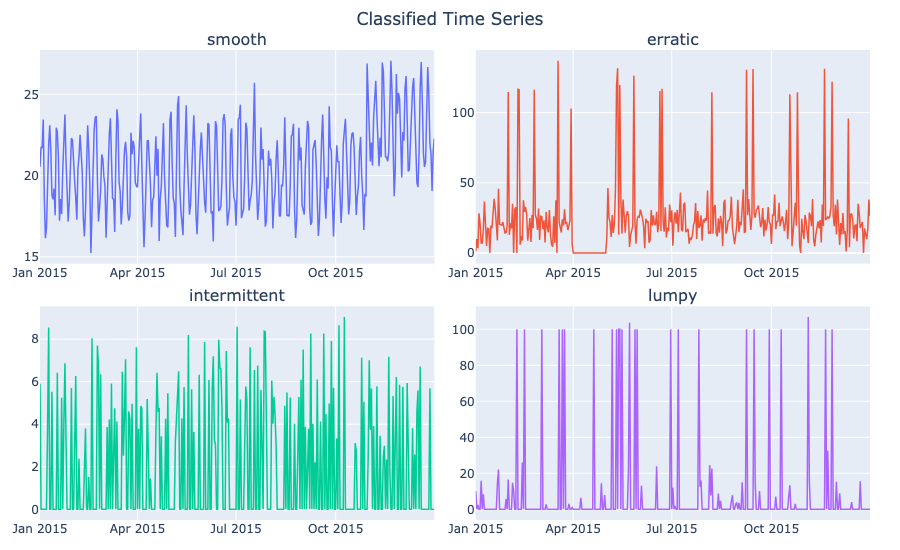

In [3]:
classifiedSeriesPlot(data=data.droplevel([1, 2]), title="Classified Time Series")

In [ ]:
data.to_parquet("../data/test/unit_test_synthetic.pq")

# Sliced train data

In [5]:
data, column = pd.read_parquet("../data/processed/sales.pq"), "sales"

In [ ]:
mapper = Mapper()
temp = mapper.fit_transform(data)
temp.head()  # type: ignore

sales
index date             
0     2015-08-31    6.0
      2015-09-01    1.0
      2015-09-02    4.0
      2015-09-03    2.0
      2015-09-04    0.0

In [ ]:
# Random extraction specific number of series from each demand class

result, t = DemandClassifier().fit_transform(temp).reset_index().set_index("class"), []  # type: ignore

for x in result.index.unique():
    t += list(np.random.choice(result.loc[x]["index"], size=5, replace=False))
else:
    result = (
        result[result["index"].isin(t)]
        .set_index("index", append=True)[[]]
        .join(temp)
        .sort_index()
    )

In [ ]:
result.to_parquet("../data/test/integration_test_sliced_train.pq")